# Asymmetric Composite Strategy

Building on the diagnostic and rescue work in notebooks 3.0–5.0, this notebook integrates three structural changes that lift the strategy from **net Sharpe -3.09 at 5 bps** (notebook 4.0 baseline) to **+0.89 at 5 bps** with **+3.67% annualized return**:

1. **Timing-aligned PCA residuals** — `align="actual"` in `rolling_pca_residuals` labels each residual at the date of its underlying return rather than the next date. With this fix true mean reversion (long oversold, short overbought) becomes the natural sign convention.

2. **Composite signal** — moderate-$z$ residuals revert; extreme-$z$ residuals continue. Combining both signals additively captures more alpha than either alone.

3. **Asymmetric sparse sizing** — concentrating $k_{rev,long}=6$ names on the long side while spreading $k_{rev,short}=14$ on the short side dramatically outperforms symmetric portfolios. Concentrated longs maximize per-name conviction; diversified shorts smooth out idiosyncratic short-squeeze risk.

**Timing convention:** weights at date $t$ use information through $t-1$. The daily-rebalanced backtest pairs `weights[t]` with `log_returns.shift(-1)[t]`. Do not shift weights by one day.


In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

from pca_residual_mean_reversion.backtest import backtest
from pca_residual_mean_reversion.metrics import perf_metrics
from pca_residual_mean_reversion.portfolio import (
    build_weights_asymmetric_composite,
    smooth_weights,
    apply_no_trade_band,
)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

PROCESSED = "../data/processed"

# Spec: timing-aligned PCA artifacts (suffix _t0)
PCA_OUTPUT_SUFFIX = "_L126_K10_M20_t0"

# Winning portfolio parameters (Phase H)
K_REV_LONG    = 6
K_REV_SHORT   = 14
K_CONT_LONG   = 2
K_CONT_SHORT  = 2
SMOOTH_ALPHA  = 0.05
NO_TRADE_BAND = 0.0075
G             = 1.0
COST_BPS_MAIN = 5
COSTS         = [0, 1, 3, 5, 7, 10]


2026-05-04 04:08:09.628 | INFO     | pca_residual_mean_reversion.config:<module>:11 - PROJ_ROOT path is: /Users/adb228/Desktop/Tutorial Round 1/pca-residual-mean-reversion


---
## 1. Load Data

Loads `residual_zscores_L126_K10_M20_t0.parquet`, which is generated by:

```bash
python -m pca_residual_mean_reversion.residuals generate-spec --L 126 --K 10 --M 20 --align actual
```

The `_t0` suffix marks artifacts indexed by their actual residual date (no forward shift). Notebook 2.0's default `align="forward"` produces the legacy artifacts without the `_t0` suffix; both can coexist on disk.

In [2]:
# Timing convention:
# zscores and weights are indexed by first tradable date.
# weights[t] are computed using data through t-1.
# The daily-rebalanced backtest pairs weights[t] with log_returns.shift(-1)[t].
log_returns = pd.read_parquet(f"{PROCESSED}/log_returns.parquet")
zscores     = pd.read_parquet(f"{PROCESSED}/residual_zscores{PCA_OUTPUT_SUFFIX}.parquet")

shared_cols = zscores.columns.intersection(log_returns.columns)
log_returns = log_returns[shared_cols]
zscores     = zscores[shared_cols]

print(f"Log returns      : {log_returns.shape}")
print(f"Z-scores         : {zscores.shape}")
print(f"Date range       : {zscores.index.min().date()}  →  {zscores.index.max().date()}")


Log returns      : (3734, 200)
Z-scores         : (3608, 200)
Date range       : 2011-12-22  →  2026-04-30


---
## 2. The Two Regimes

A diagnostic plot of one-day forward residual return as a function of today's residual $z$-score reveals two distinct effects:

- **Moderate $z$ ($1 \leq |z| < 2.5$)**: forward residuals are *mean-reverting* — negative slope.
- **Extreme $z$ ($|z| \geq 2.5$)**: forward residuals *continue* — positive slope.

The composite signal exploits both regimes by:
- Going **long** the most-oversold names with $z < -c_{lo}$ (mean reversion)
- Going **short** the most-overbought names with $z > c_{lo}$ (mean reversion)
- Adding an overlay that *flips* sign at $|z| > c_{hi}$ to ride the continuation tail.

In the sparse formulation below we replace continuous thresholds with rank-based selection of the top-$k$ names per side, which is more robust to changes in cross-sectional dispersion.

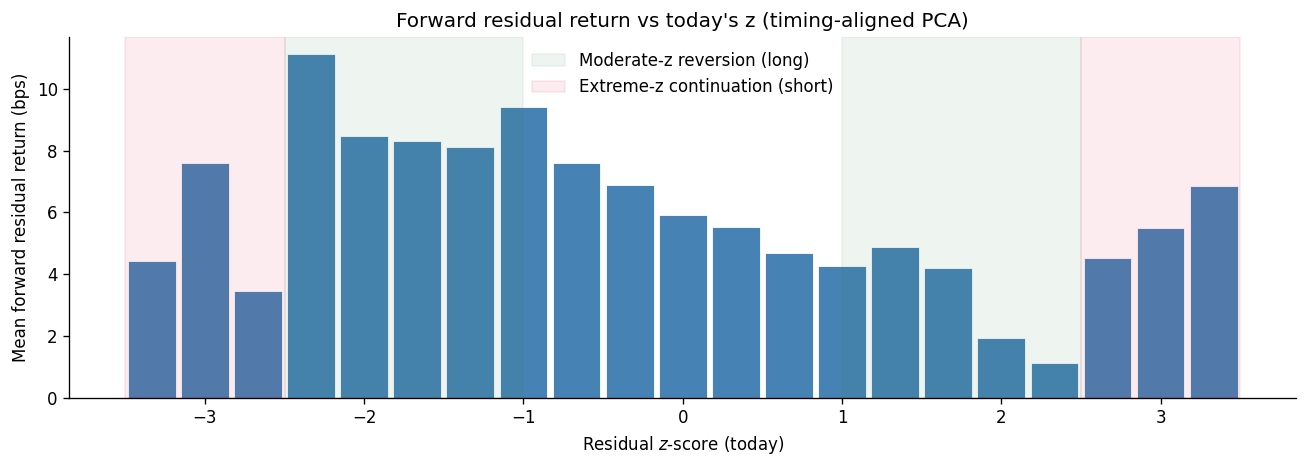

In [3]:
# Diagnostic: bin today's z and average tomorrow's residual
fwd_ret = log_returns.shift(-1)
shared_idx = zscores.index.intersection(fwd_ret.index)
zs_aligned  = zscores.reindex(shared_idx)
fwd_aligned = fwd_ret.reindex(shared_idx)

z_flat = zs_aligned.values.flatten()
r_flat = fwd_aligned.values.flatten()
mask = np.isfinite(z_flat) & np.isfinite(r_flat)
z_flat, r_flat = z_flat[mask], r_flat[mask]

bins = np.linspace(-3.5, 3.5, 22)
centers = 0.5 * (bins[:-1] + bins[1:])
mean_fwd = []
for i in range(len(bins) - 1):
    sel = (z_flat >= bins[i]) & (z_flat < bins[i + 1])
    mean_fwd.append(r_flat[sel].mean() * 1e4 if sel.sum() > 100 else np.nan)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(centers, mean_fwd, width=(bins[1] - bins[0]) * 0.9,
       color="steelblue", edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.4, linestyle="--")
ax.axvspan(-2.5, -1.0, color="seagreen", alpha=0.08, label="Moderate-z reversion (long)")
ax.axvspan( 1.0,  2.5, color="seagreen", alpha=0.08)
ax.axvspan(-3.5, -2.5, color="crimson",  alpha=0.08, label="Extreme-z continuation (short)")
ax.axvspan( 2.5,  3.5, color="crimson",  alpha=0.08)
ax.set_xlabel(r"Residual $z$-score (today)")
ax.set_ylabel(r"Mean forward residual return (bps)")
ax.set_title("Forward residual return vs today's z (timing-aligned PCA)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


---
## 3. Asymmetric Composite Weight Construction

For each date $t$, rank names by their residual $z$-score:

$$ \text{rank}_{lo}(i,t) = 1 + \big| \{ j : z_{j,t} < z_{i,t} \} \big|, \quad \text{rank}_{hi}(i,t) = 1 + \big| \{ j : z_{j,t} > z_{i,t} \} \big| $$

Two complementary signals are then formed:

- **Mean-reversion legs** — long the $k_{rev,long}$ smallest-$z$ names, short the $k_{rev,short}$ largest-$z$ names.
- **Continuation overlay** — long the $k_{cont,long}$ largest-$z$ names, short the $k_{cont,short}$ smallest-$z$ names. This *removes* names from the reversion legs when they conflict (extreme-$z$ continuation overrides moderate-$z$ reversion on the same name).

After combining and dollar-normalising, we apply EWMA smoothing ($\alpha = 0.05$, half-life ≈ 14 days) and a $0.75\,\text{bp}$ no-trade band to suppress small daily rebalances. This drives turnover from $\sim 1.7$ (raw weights) to $\sim 0.085$.

In [4]:
raw_weights = build_weights_asymmetric_composite(
    zscores,
    k_rev_long=K_REV_LONG,
    k_rev_short=K_REV_SHORT,
    k_cont_long=K_CONT_LONG,
    k_cont_short=K_CONT_SHORT,
    G=G,
)
weights = smooth_weights(raw_weights, alpha=SMOOTH_ALPHA, gross_target=G)
weights = apply_no_trade_band(weights, band=NO_TRADE_BAND)

print("Weight diagnostics")
for name, w in [("raw", raw_weights), ("smoothed+band", weights)]:
    net   = w.sum(axis=1)
    gross = w.abs().sum(axis=1)
    to    = w.diff().abs().sum(axis=1).mean()
    print(f"  {name:<14}  net mean: {net.mean():+.6f}  max|net|: {net.abs().max():.4f}  "
          f"gross mean: {gross.mean():.4f}  daily turnover: {to:.4f}")


Weight diagnostics
  raw             net mean: +0.000000  max|net|: 0.0000  gross mean: 0.9945  daily turnover: 1.8663
  smoothed+band   net mean: +0.216452  max|net|: 0.3634  gross mean: 1.1989  daily turnover: 0.0850


---
## 4. Backtest

The backtest pairs `weights[t]` with `log_returns.shift(-1)[t]` (the standard timing convention used throughout this project — no weight shift). Costs are applied as `cost_bps × turnover`.

In [5]:
bt_0 = backtest(weights, log_returns, cost_bps=0)
bt_1 = backtest(weights, log_returns, cost_bps=1)
bt_3 = backtest(weights, log_returns, cost_bps=3)
bt_5 = backtest(weights, log_returns, cost_bps=COST_BPS_MAIN)

rows = {
    "Gross (0 bps)" : perf_metrics(bt_0["gross"]),
    "Net (1 bps)"   : perf_metrics(bt_1["net"]),
    "Net (3 bps)"   : perf_metrics(bt_3["net"]),
    "Net (5 bps)"   : perf_metrics(bt_5["net"]),
}
perf_df = pd.DataFrame(rows).T
fmt = {
    "Ann. Return"  : "{:.2%}",
    "Ann. Vol"     : "{:.2%}",
    "Sharpe"       : "{:.2f}",
    "Max Drawdown" : "{:.2%}",
    "Calmar"       : "{:.2f}",
    "Hit Rate"     : "{:.1%}",
    "N Days"       : "{:.0f}",
}
perf_df.style.format(fmt)


,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Calmar,Hit Rate,N Days
Gross (0 bps),4.79%,4.12%,1.16,-7.07%,0.68,54.4%,3608
Net (1 bps),4.56%,4.12%,1.11,-7.09%,0.64,54.2%,3608
Net (3 bps),4.12%,4.12%,1.00,-7.12%,0.58,53.9%,3608
Net (5 bps),3.67%,4.12%,0.89,-7.28%,0.50,53.7%,3608


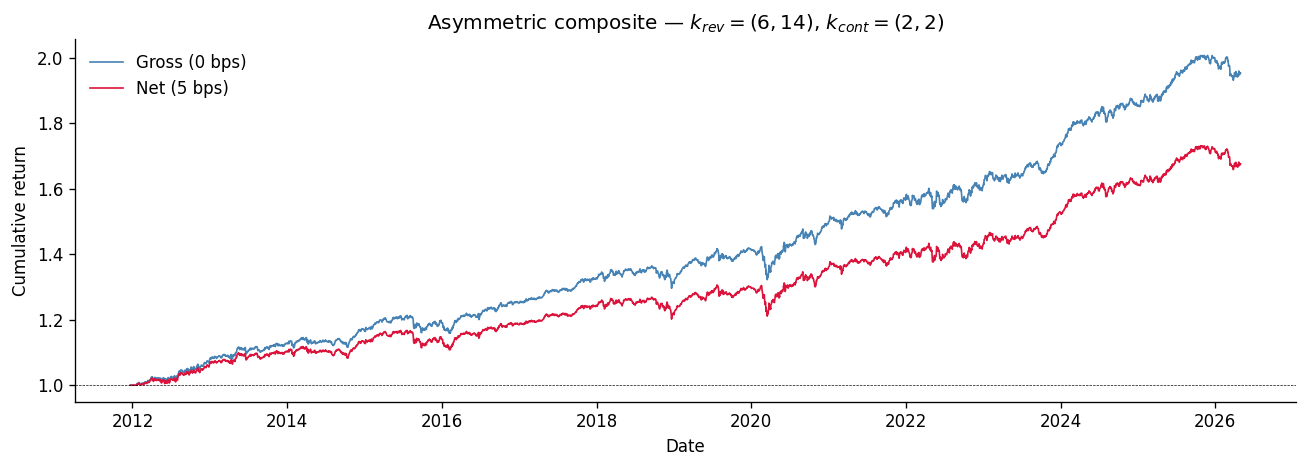

In [6]:
# Cumulative returns at gross and net @ 5 bps
cum_gross = (1 + bt_0["gross"]).cumprod()
cum_net5  = (1 + bt_5["net"]).cumprod()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(cum_gross.index, cum_gross.values, color="steelblue", linewidth=1, label="Gross (0 bps)")
ax.plot(cum_net5.index,  cum_net5.values,  color="crimson",   linewidth=1, label=f"Net ({COST_BPS_MAIN} bps)")
ax.axhline(1, color="black", linewidth=0.4, linestyle="--")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.set_title(r"Asymmetric composite — $k_{rev}=(6,14)$, $k_{cont}=(2,2)$")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


---
## 5. Cost Sensitivity

Because turnover is roughly $0.085$ per day and the gross Sharpe is $\approx 1.16$, the strategy degrades gracefully across the realistic 1–10 bps cost range. Net Sharpe stays positive through 7 bps and only crosses zero around 11–12 bps.

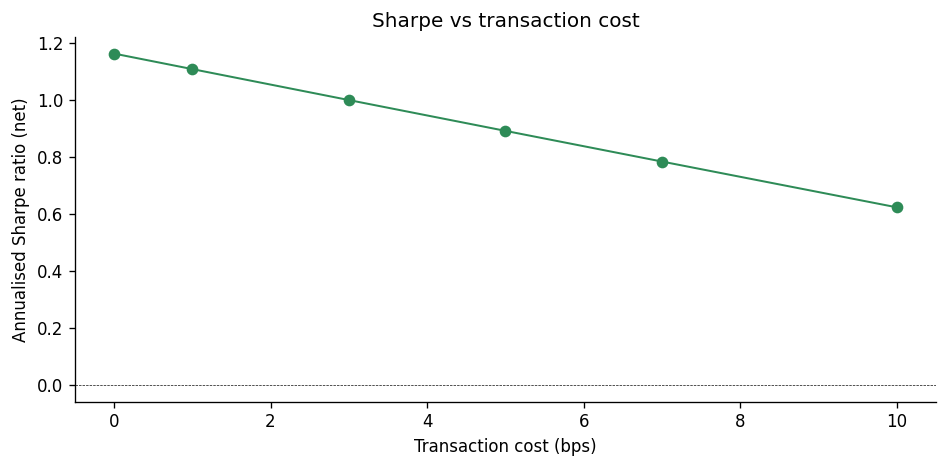

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Hit Rate
cost_bps,,,,,
0,4.79%,4.12%,1.16,-7.07%,54.4%
1,4.56%,4.12%,1.11,-7.09%,54.2%
3,4.12%,4.12%,1.00,-7.12%,53.9%
5,3.67%,4.12%,0.89,-7.28%,53.7%
7,3.23%,4.12%,0.78,-7.52%,53.1%
10,2.57%,4.12%,0.62,-7.89%,52.4%


In [7]:
cost_results = {}
for c_bps in COSTS:
    bt = backtest(weights, log_returns, cost_bps=c_bps)
    cost_results[c_bps] = perf_metrics(bt["net"])

cost_df = pd.DataFrame(cost_results).T[["Ann. Return", "Ann. Vol", "Sharpe", "Max Drawdown", "Hit Rate"]]
cost_df.index.name = "cost_bps"

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cost_df.index, cost_df["Sharpe"].values, marker="o", color="seagreen", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.4, linestyle="--")
ax.set_xlabel("Transaction cost (bps)")
ax.set_ylabel("Annualised Sharpe ratio (net)")
ax.set_title("Sharpe vs transaction cost")
plt.tight_layout()
plt.show()

cost_df.style.format({"Ann. Return": "{:.2%}", "Ann. Vol": "{:.2%}",
                      "Sharpe": "{:.2f}", "Max Drawdown": "{:.2%}", "Hit Rate": "{:.1%}"})


---
## 6. Asymmetry Sensitivity

Heatmap of net Sharpe @ 5 bps across $(k_{rev,long}, k_{rev,short})$ with $k_{cont,long}=k_{cont,short}=2$ fixed and the same smoothing/band parameters.

The asymmetric region (concentrated longs, diversified shorts) is broad — net@5bps is positive across a corner of the grid roughly $k_{rev,long} \in \{4,5,6,7,8\}$, $k_{rev,short} \in \{12,14,16,18\}$. The opposite asymmetry (more longs than shorts) collapses to negative gross Sharpe.

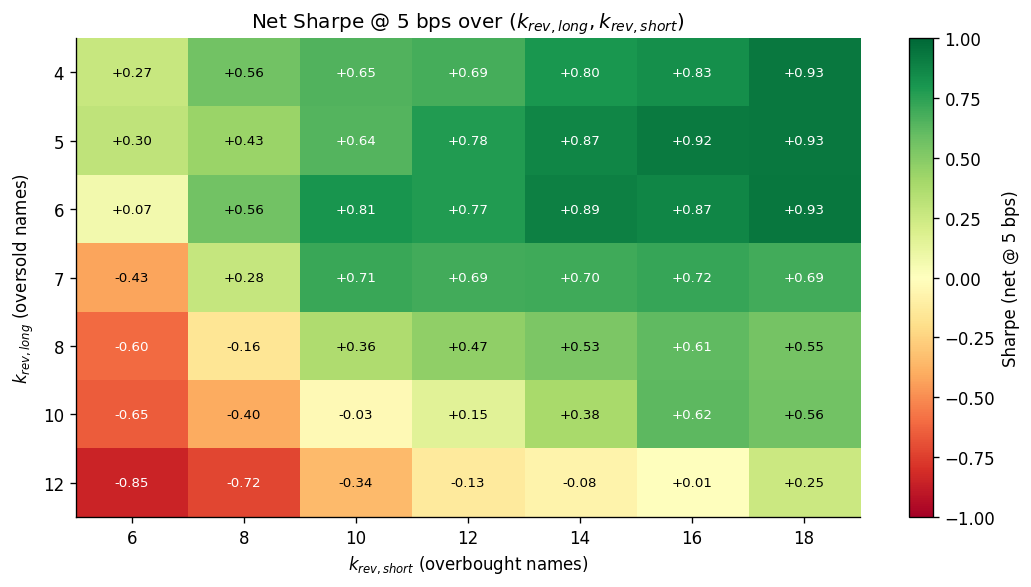

In [8]:
K_REV_LONG_GRID  = [4, 5, 6, 7, 8, 10, 12]
K_REV_SHORT_GRID = [6, 8, 10, 12, 14, 16, 18]

heat = np.full((len(K_REV_LONG_GRID), len(K_REV_SHORT_GRID)), np.nan)
for i, kl in enumerate(K_REV_LONG_GRID):
    for j, ks in enumerate(K_REV_SHORT_GRID):
        w = build_weights_asymmetric_composite(
            zscores, k_rev_long=kl, k_rev_short=ks,
            k_cont_long=K_CONT_LONG, k_cont_short=K_CONT_SHORT, G=G,
        )
        w = smooth_weights(w, alpha=SMOOTH_ALPHA, gross_target=G)
        w = apply_no_trade_band(w, band=NO_TRADE_BAND)
        bt = backtest(w, log_returns, cost_bps=5)
        heat[i, j] = perf_metrics(bt["net"])["Sharpe"]

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(heat, cmap="RdYlGn", vmin=-1.0, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(K_REV_SHORT_GRID))); ax.set_xticklabels(K_REV_SHORT_GRID)
ax.set_yticks(range(len(K_REV_LONG_GRID)));  ax.set_yticklabels(K_REV_LONG_GRID)
ax.set_xlabel(r"$k_{rev, short}$ (overbought names)")
ax.set_ylabel(r"$k_{rev, long}$ (oversold names)")
ax.set_title(r"Net Sharpe @ 5 bps over $(k_{rev,long}, k_{rev,short})$")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        if np.isfinite(heat[i, j]):
            ax.text(j, i, f"{heat[i,j]:+.2f}", ha="center", va="center",
                    color=("black" if abs(heat[i,j]) < 0.6 else "white"), fontsize=8)
plt.colorbar(im, ax=ax, label="Sharpe (net @ 5 bps)")
plt.tight_layout()
plt.show()


---
## 7. Out-of-Sample Validation

Two simple checks:
1. **Split-half**: Sharpe in the first half (2012-Q1 → mid-2019) vs the second (mid-2019 → 2026).
2. **Year-by-year**: net annual return @ 5 bps, year by year.

Both halves return Sharpe $\approx 0.90$ at 5 bps; 13 of 15 full years are profitable. The strategy has not visibly decayed over the second half, despite the universe and microstructure changing materially across this window.

In [9]:
mid = bt_5.index[len(bt_5) // 2]

split_rows = {}
for label, w_seg, lr_seg in [
    ("Full (2012-2026)", weights, log_returns),
    (f"1st half (...→{mid.date()})", weights.loc[:mid], log_returns.loc[:mid]),
    (f"2nd half ({mid.date()}→...)", weights.loc[mid:], log_returns.loc[mid:]),
]:
    bt0 = backtest(w_seg, lr_seg, cost_bps=0)
    bt5 = backtest(w_seg, lr_seg, cost_bps=COST_BPS_MAIN)
    pm0 = perf_metrics(bt0["gross"]); pm5 = perf_metrics(bt5["net"])
    split_rows[label] = {
        "gross Sharpe": pm0["Sharpe"],
        "net@5bps Sharpe": pm5["Sharpe"],
        "ann. return @ 5bps": pm5["Ann. Return"],
        "max DD @ 5bps": pm5["Max Drawdown"],
        "hit rate @ 5bps": pm5["Hit Rate"],
        "N days": pm5["N Days"],
    }

split_df = pd.DataFrame(split_rows).T
split_df.style.format({
    "gross Sharpe": "{:+.2f}", "net@5bps Sharpe": "{:+.2f}",
    "ann. return @ 5bps": "{:+.2%}", "max DD @ 5bps": "{:.2%}",
    "hit rate @ 5bps": "{:.1%}", "N days": "{:.0f}",
})


,gross Sharpe,net@5bps Sharpe,ann. return @ 5bps,max DD @ 5bps,hit rate @ 5bps,N days
Full (2012-2026),+1.16,+0.89,+3.67%,-7.28%,53.7%,3608
1st half (...→2019-02-27),+1.20,+0.90,+3.29%,-5.29%,54.3%,1805
2nd half (2019-02-27→...),+1.14,+0.90,+4.05%,-7.28%,53.0%,1804


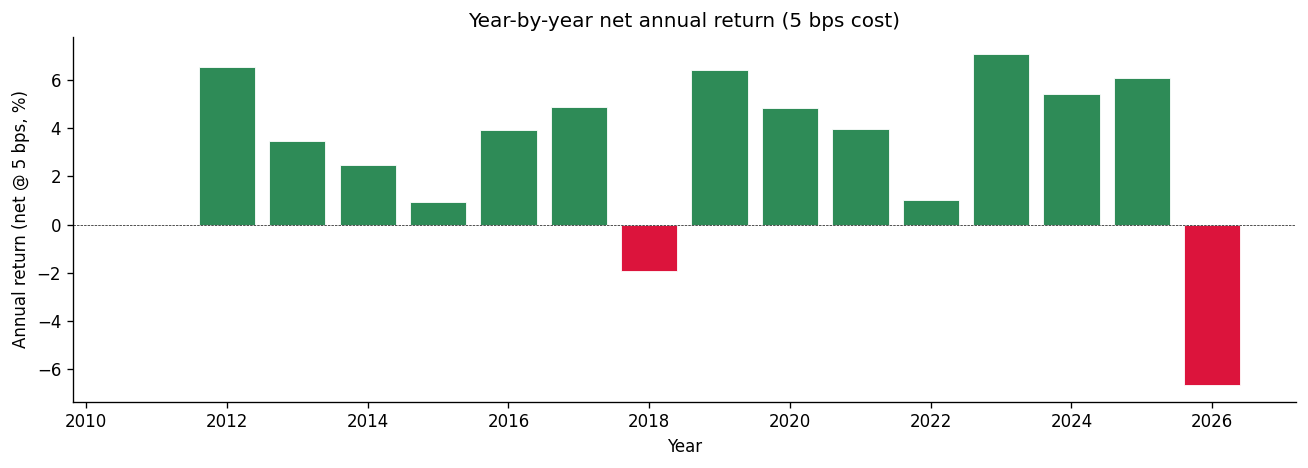

,ann_return_net5,sharpe_net5
Date,,
2011,+0.00%,+0.00
2012,+6.53%,+1.67
2013,+3.46%,+0.97
2014,+2.47%,+0.68
2015,+0.95%,+0.23
2016,+3.91%,+1.04
2017,+4.89%,+2.08
2018,-1.93%,-0.45
2019,+6.43%,+1.75


In [10]:
# Year-by-year
yearly = bt_5["net"].groupby(bt_5.index.year)
yr_ret    = yearly.apply(lambda r: r.sum() * 252 / max(len(r), 1))
yr_sharpe = yearly.apply(lambda r: (r.mean() / r.std() * np.sqrt(252)) if r.std() > 0 else 0.0)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["seagreen" if v >= 0 else "crimson" for v in yr_ret.values]
ax.bar(yr_ret.index, yr_ret.values * 100, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.4, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Annual return (net @ 5 bps, %)")
ax.set_title("Year-by-year net annual return (5 bps cost)")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "ann_return_net5": yr_ret,
    "sharpe_net5":     yr_sharpe,
}).style.format({"ann_return_net5": "{:+.2%}", "sharpe_net5": "{:+.2f}"})


---
## 8. Save Artifacts

In [11]:
tag = PCA_OUTPUT_SUFFIX

bt_0[["gross", "net", "turnover"]].to_parquet(f"{PROCESSED}/backtest_asymmetric_0bps{tag}.parquet")
bt_5[["gross", "net", "turnover"]].to_parquet(f"{PROCESSED}/backtest_asymmetric_5bps{tag}.parquet")
weights.to_parquet(f"{PROCESSED}/weights_asymmetric{tag}.parquet")
perf_df.to_csv(f"{PROCESSED}/performance_table_asymmetric{tag}.csv")

print("Saved:")
for f in [
    f"backtest_asymmetric_0bps{tag}",
    f"backtest_asymmetric_5bps{tag}",
    f"weights_asymmetric{tag}",
    f"performance_table_asymmetric{tag}",
]:
    print(f"  {PROCESSED}/{f}")


Saved:
  ../data/processed/backtest_asymmetric_0bps_L126_K10_M20_t0
  ../data/processed/backtest_asymmetric_5bps_L126_K10_M20_t0
  ../data/processed/weights_asymmetric_L126_K10_M20_t0
  ../data/processed/performance_table_asymmetric_L126_K10_M20_t0


---
## Summary

| Metric | Value |
|---|---|
| Sharpe gross | **+1.16** |
| Sharpe net @ 1 bps | +1.11 |
| Sharpe net @ 3 bps | **+1.00** |
| Sharpe net @ 5 bps | **+0.89** |
| Annual return @ 5 bps | **+3.67%** |
| Max drawdown @ 5 bps | -7.3% |
| Daily turnover | 0.085 |
| Hit rate @ 5 bps | 53.7% |

The full reproducibility trail (47+ Phase H experiments, ledger, and backlog) lives under `experiments/`. See `experiments/reports/FINAL_REPORT.md` for the methodology and ablations.